In [73]:
# Loading stuff

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.linear_model import Lasso, ElasticNet

In [74]:
# --- Loading all the datasets
# Train dataset
train_dataset = pd.read_csv('data/train_radiomics_hipocamp.csv')
# Test dataset
test_dataset = pd.read_csv('data/test_radiomics_hipocamp.csv')

In [75]:
# --- Exploring the train dataset
train_dataset.head()
train_dataset.columns
train_dataset.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 2181 columns):
 #     Column                                                         Non-Null Count  Dtype  
---    ------                                                         --------------  -----  
 0     ID                                                             305 non-null    object 
 1     Image                                                          305 non-null    object 
 2     Mask                                                           305 non-null    object 
 3     diagnostics_Versions_PyRadiomics                               305 non-null    object 
 4     diagnostics_Versions_Numpy                                     305 non-null    object 
 5     diagnostics_Versions_SimpleITK                                 305 non-null    object 
 6     diagnostics_Versions_PyWavelet                                 305 non-null    object 
 7     diagnostics_Versions_Python             

In [76]:
# --- Removing columns with irrelevant information

# Getting all columns whose value is an object
obj_col = train_dataset.select_dtypes(include='object').columns

# Storing in a list the columns that have the same number of unique values as the number of rows
# This means that the column is a unique identifier and probably should be dropped
unique_cols = []
for col in obj_col:
    if train_dataset[col].nunique() == 305:
        unique_cols.append(col)
        
# Dropping the columns stored in the unique_cols list
train_dataset.drop(unique_cols, axis=1, inplace=True)
# Dropping them from the test dataset as well
test_dataset.drop(unique_cols, axis=1, inplace=True)

In [77]:
train_dataset.shape

(305, 2173)

In [1100]:
# Drop constant features
train_dataset = train_dataset.loc[:, (train_dataset != train_dataset.iloc[0]).any()]
# Dropping the same columns on the test dataset
test_dataset = test_dataset[train_dataset.drop(columns='Transition').columns]

In [1101]:
# Drop constant features
train_dataset.shape

(305, 2014)

In [1102]:
# --- Checking all unique values in the Transition column
train_dataset['Transition'].value_counts()
# Dataset is extremely UNBALANCED

Transition
CN-CN      96
MCI-MCI    71
MCI-AD     68
AD-AD      60
CN-MCI     10
Name: count, dtype: int64

In [1103]:
# --- Using encoding to transform the categorical columns into numerical columns
replace_map = {'Transition': {'CN-CN': 0, 'AD-AD': 1, 'CN-MCI': 2, 'MCI-AD': 3, 'MCI-MCI': 4}}
train_dataset.replace(replace_map, inplace=True)
test_dataset.replace(replace_map, inplace=True)
train_dataset.head()

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_10560\4011534618.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_dataset.replace(replace_map, inplace=True)


,diagnostics_Image-original_Mean,diagnostics_Image-original_Maximum,diagnostics_Mask-original_VoxelNum,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,...,lbp-3D-k_glszm_ZonePercentage,lbp-3D-k_glszm_ZoneVariance,lbp-3D-k_ngtdm_Busyness,lbp-3D-k_ngtdm_Coarseness,lbp-3D-k_ngtdm_Complexity,lbp-3D-k_ngtdm_Contrast,lbp-3D-k_ngtdm_Strength,Sex,Age,Transition
0,5.848123,178,7106,0.420040,0.106547,10.757474,100.964915,72.034714,71.175839,43.416587,...,0.007881,345733.167092,479.414935,0.001538,0.183049,0.017044,0.001581,0,77.1,0
1,5.238834,190,7779,0.425482,0.102532,10.432362,101.747321,73.246160,73.109507,44.102154,...,0.013112,244310.331892,378.001763,0.001761,0.146021,0.010782,0.001813,1,83.4,0
2,6.816667,155,6707,0.447685,0.135582,14.370911,105.993915,79.762146,79.056942,47.853944,...,0.011331,222776.529605,497.261162,0.001567,0.190309,0.019644,0.001596,1,81.3,1
3,6.445162,171,8281,0.418896,0.099626,10.639815,106.797600,78.102497,77.006493,45.793013,...,0.012197,280222.663268,406.837667,0.001629,0.148247,0.010824,0.001677,1,79.6,2
4,5.568269,150,5986,0.411851,0.080719,8.885188,110.075144,75.432089,75.239617,43.462628,...,0.010859,216779.591479,368.838125,0.001912,0.174701,0.014793,0.001979,0,80.1,0


In [1104]:
train_dataset['Transition'].value_counts()

Transition
0    96
4    71
3    68
1    60
2    10
Name: count, dtype: int64

In [1105]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Columns: 2014 entries, diagnostics_Image-original_Mean to Transition
dtypes: float64(1994), int64(20)
memory usage: 4.7 MB


In [1106]:
# --- Droppig non-target columns with the same info (correlation = 1 between them)

#target_column = 'Transition'  
## Calculating the correlation matrix (excluding the target column and the ID column)
#train_dataset_tmp = train_dataset 
#corr_matrix_train = train_dataset_tmp.drop(columns=[target_column]).corr().abs()
#
## Upper triangle matrix of correlations
#upper = corr_matrix_train.where(np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool))
#
## Finding index of feature columns with correlation equal to 1
#threshold = 1.0
#to_drop = [column for column in upper.columns if any(upper[column] >= threshold)] # for some reason there are columns with correlation > 1.0
#print("dropping " + str(len(to_drop)) + " columns")
#
## Dropping the columns
#train_dataset = train_dataset.drop(columns=to_drop)
#test_dataset = test_dataset.drop(columns=to_drop)

In [1107]:
# Checking dataset info
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Columns: 2014 entries, diagnostics_Image-original_Mean to Transition
dtypes: float64(1994), int64(20)
memory usage: 4.7 MB


In [1108]:
## --- Dropping columns with low correlation with the target column (<0.005)

#corr_matrix = train_dataset.corr()
#corr_target = corr_matrix['Transition'].abs()
#uncorr_cols = []
#for i in range(len(corr_target)):
#    if corr_target[i] < 0.005:
#        uncorr_cols.append(corr_matrix.columns[i])
#
## Dropping the columns stored in the uncorr_cols list
#n_cols_before = len(train_dataset.columns)
#train_dataset.drop(uncorr_cols, axis=1, inplace=True)
#test_dataset.drop(uncorr_cols, axis=1, inplace=True)
#n_cols_after = len(train_dataset.columns)
#
#print("Dropped " + str(n_cols_before-n_cols_after) + " columns!")

Axes(0.125,0.11;0.775x0.77)


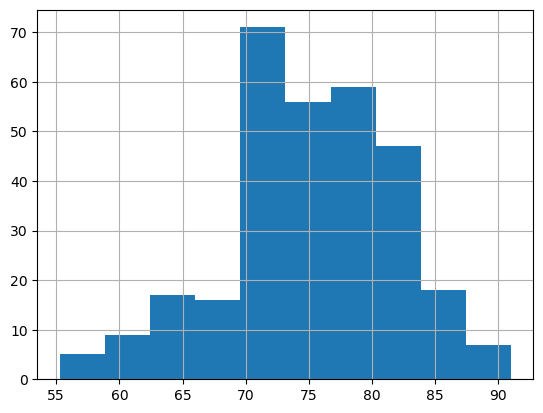

In [1109]:
# --- Checking Age column
print(train_dataset['Age'].hist())
plt.show()
# Not a normal distribution

In [1110]:
# --- Checking Sex column
print(train_dataset['Sex'].value_counts(normalize=True))
# Not quite balanced

Sex
1    0.567213
0    0.432787
Name: proportion, dtype: float64


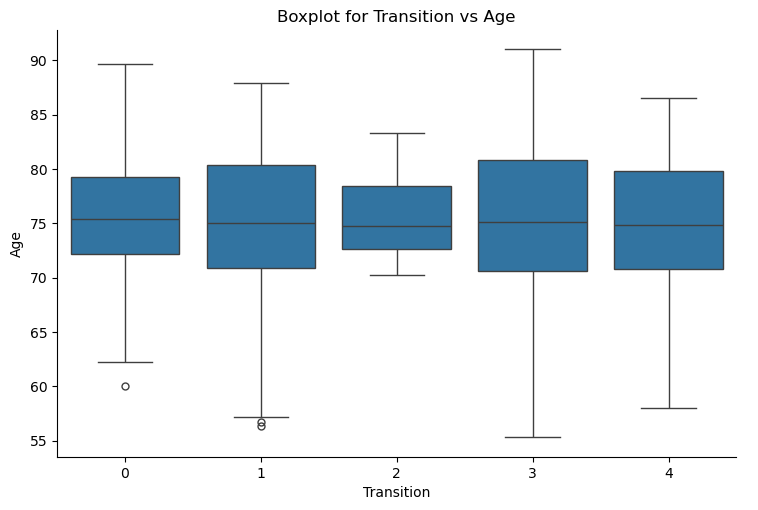

In [1111]:
# --- Understanding the relationship between Age and Transition
sns.catplot(x="Transition", y="Age", data=train_dataset, kind="box", aspect=1.5)
plt.title("Boxplot for Transition vs Age")
plt.show()

In [1112]:
# --- Treating outliers in all columns
# Outliers should be converted to the closest bound

changes_count = 0

for col in train_dataset.columns:
    if col not in ['Transition', 'ID']:
        median = train_dataset[col].median()
        q1 = train_dataset[col].quantile(0.25)
        q3 = train_dataset[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Count outliers before replacing them
        changes_count += ((train_dataset[col] < lower_bound) | (train_dataset[col] > upper_bound)).sum()
        changes_count += ((test_dataset[col] < lower_bound) | (test_dataset[col] > upper_bound)).sum()
        
        # Replace outliers with the median
        # train_dataset[col] = train_dataset[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)
        # test_dataset[col] = test_dataset[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

        # Replace outliers with the closest bound
        train_dataset[col] = train_dataset[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
        test_dataset[col] = test_dataset[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

print(f"Total number of changes made: {changes_count}")

Total number of changes made: 27301


In [1113]:
X = train_dataset.drop(columns=['Transition'])
y = train_dataset['Transition']

In [1114]:
# --- Standardizing data to apply feature selection and dimensionality reduction

scaler = StandardScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=train_dataset.drop(columns=['Transition']).columns)

test_dataset = scaler.transform(test_dataset)  # Use same scaler for test data
test_dataset = pd.DataFrame(test_dataset, columns=train_dataset.drop(columns=['Transition']).columns)

In [1115]:
# Add an 'oversampled' column to the dataset with 'NO' values
# This will be used to guarantee oversampling data is not used in testing
train_dataset['oversampled'] = 'NO'

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_10560\3994889019.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_dataset['oversampled'] = 'NO'


In [1116]:
# --- Oversampling data
### Oversampling should be done after standardizing but before feature selection and dimensionality reduction
#
## Split the dataset into features and target
#X = train_dataset.drop(columns=['Transition', 'oversampled'])
#y = train_dataset['Transition']
#
## Identify the majority class count (class '0')
#majority_class_count = y.value_counts().loc[0]
#
## Set the target count for class '2' to be 0.5 of the majority class count
#target_class_2_count = int(majority_class_count * 0.3)
#target_class_1_count = int(majority_class_count * 1)
#target_class_3_count = int(majority_class_count * 1)
#target_class_4_count = int(majority_class_count * 1)
#
## Define a sampling strategy where only class '2' is oversampled to the target count
#sampling_strategy = {2: target_class_2_count,
##                     1: target_class_1_count,
##                     3: target_class_3_count,
##                     4: target_class_4_count
#}
#
## Apply SMOTE with the defined strategy
#smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
#X_smote, y_smote = smote.fit_resample(X, y)
#
## Create a new dataframe with the oversampled data
#oversampled_data = pd.concat([X_smote, y_smote], axis=1)
#oversampled_data.columns = list(X.columns) + ['Transition']
#
## Mark the oversampled rows with 'YES' in the 'oversampled' column
#oversampled_data['oversampled'] = ['YES' if idx >= len(X) else 'NO' for idx in range(len(X_smote))]
#
## Concatenate the new oversampled data with the original data
#train_dataset = pd.concat([train_dataset, oversampled_data[oversampled_data['oversampled'] == 'YES']], ignore_index=True)
#
## Display the final class distribution for verification
#print("Class distribution after SMOTE oversampling:")
#print(train_dataset['Transition'].value_counts())
#
## --- Getting the number of normal and oversampled data
#train_dataset['oversampled'].value_counts()
#
#X = train_dataset.drop(columns=['Transition','oversampled'])
#y = train_dataset['Transition']

In [1117]:
# --- Feature selection with ANOVA

f, p = f_classif(X, y)
f_classif_importances = f
features_to_keep = X.columns[f_classif_importances.argsort()[-100:]]
## Keeping only the selected features
X = X[list(features_to_keep)]
# Dropping the non-selected columns from the test dataset as well
test_dataset = test_dataset[features_to_keep]
print('Number of features:', len(features_to_keep))

Number of features: 100


/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [1787 1791] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/ricp6/miniconda3/envs/project/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [1118]:
# --- Dimensionality reduction with PCA

pca = PCA(n_components=20) 
pca.fit(X)
data = pca.transform(X)
train_dataset_no_target = pd.DataFrame(data)
train_dataset = pd.concat([train_dataset_no_target, train_dataset['Transition'], train_dataset['oversampled']], axis=1)

data_test = pca.transform(test_dataset)
test_dataset = pd.DataFrame(data_test)

In [1119]:
train_dataset.shape

(305, 22)

In [1120]:
train_dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,Transition,oversampled
0,-3.922936,1.337663,-0.780991,-0.939812,-1.701612,-0.872017,0.368473,0.001120,-0.647685,0.292971,...,0.164846,-0.378905,-0.345817,0.084805,0.174191,0.034395,-0.118602,0.242685,0,NO
1,-12.189243,0.268578,2.406573,-0.447953,2.606218,0.383441,-0.952592,0.359063,0.542347,0.376634,...,0.867781,-0.099351,0.255187,-0.305914,-0.277916,0.238758,0.120785,-0.050199,0,NO
2,19.545840,1.580911,0.104281,3.522755,-2.512932,-0.645175,0.311928,-0.854047,0.268173,1.569062,...,0.626148,0.257978,-0.029851,-0.847416,-0.361695,-0.066328,0.312578,-0.097175,1,NO
3,-9.431534,0.212322,2.153622,0.413155,-1.755673,1.041404,0.854552,-0.600823,-0.364967,-1.072817,...,0.453257,0.386869,-0.348886,0.284660,-0.256003,0.051795,-0.240423,0.411665,2,NO
4,-0.143098,-3.485711,-1.226431,-1.138905,-0.579000,1.013230,0.393585,0.261478,0.789482,-0.228535,...,-0.281441,-0.431124,-0.241300,0.487072,0.411441,-0.321667,0.164948,-0.277416,0,NO


In [1121]:
# --- Saving the treated datasets
train_dataset.to_csv('data/train_dataset.csv', index=False)
test_dataset.to_csv('data/test_dataset.csv', index=False)